In [75]:
import pickle
import flask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [76]:
df = pd.read_csv('house_price_50k.csv')
print(df.head())

   area  bedrooms  bathrooms  floors  age  distance  garage  parking  garden  \
0  1360         6          2       2    9        10       0        0       1   
1  4272         5          2       3   24         8       1        0       0   
2  3592         1          4       3    4        20       0        1       1   
3   966         5          2       2    6        14       1        0       0   
4  4926         4          3       1   18         9       0        0       0   

   security  school_nearby  hospital_nearby  shopping_mall_nearby  \
0         0              1                0                     1   
1         1              1                1                     1   
2         1              0                1                     0   
3         0              0                1                     1   
4         0              1                0                     1   

   public_transport  crime_rate  population_density location income_level  \
0                 0    6.93

In [77]:
null_count = df.isnull().sum()
print(null_count)

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64


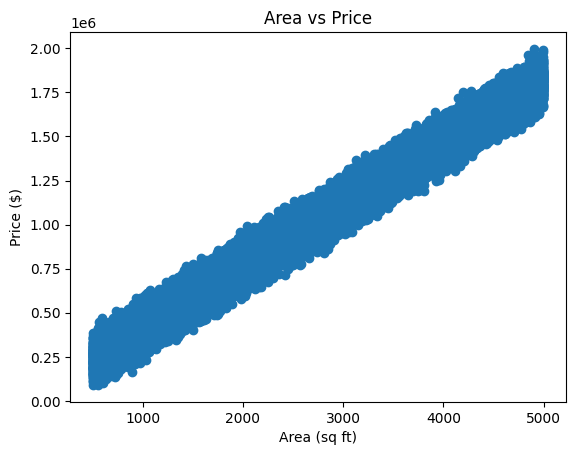

In [78]:
x = df['area']
y = df['price']
plt.scatter(x, y)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('Area vs Price')
plt.show()

In [79]:
df['income_level'].unique()

array(['low', 'mid', 'high'], dtype=object)

In [80]:
df['location'] = df['location'].map({'low': 0, 'medium': 1, 'premium': 2})
print(df['location'].head())
df['income_level'] = df['income_level'].map({'low': 0, 'mid': 1, 'high': 2})
print(df['income_level'].head())

0    2
1    0
2    2
3    1
4    0
Name: location, dtype: int64
0    0
1    0
2    1
3    0
4    1
Name: income_level, dtype: int64


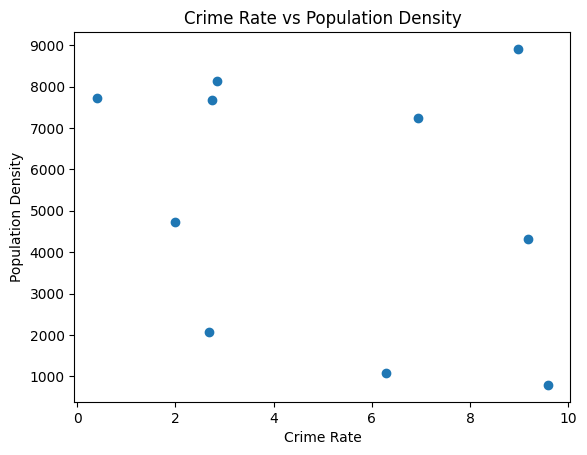

In [81]:
x = df['crime_rate'].head(10)
y = df['population_density'].head(10)
plt.scatter(x, y)
plt.xlabel('Crime Rate')
plt.ylabel('Population Density')
plt.title('Crime Rate vs Population Density')
plt.show()

<Axes: xlabel='bedrooms', ylabel='price'>

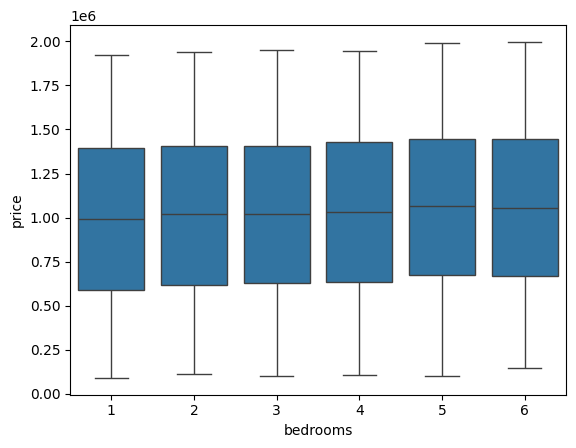

In [82]:
sns.boxplot(x="bedrooms", y="price", data=df)

<Axes: xlabel='bedrooms'>

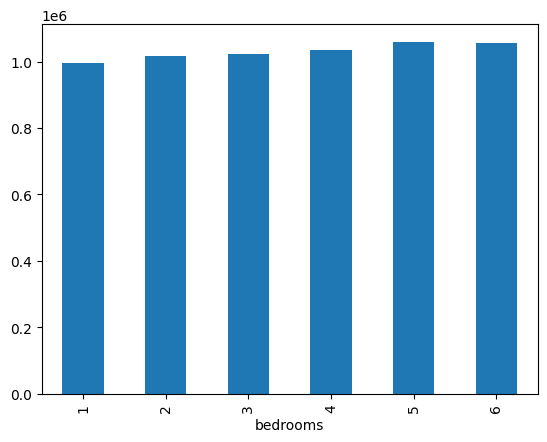

In [83]:
df.groupby("bedrooms")["price"].mean().plot(kind="bar")

In [84]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,0.99920,0.99920,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,0.81541,0.81563,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,0.00000,0.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,0.00000,0.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.00000,1.00000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,2.00000,2.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,2.00000,2.00000,1.996474e+06


In [85]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage',
       'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby',
       'shopping_mall_nearby', 'public_transport', 'crime_rate',
       'population_density', 'location', 'income_level', 'price'],
      dtype='object')

<Axes: xlabel='location'>

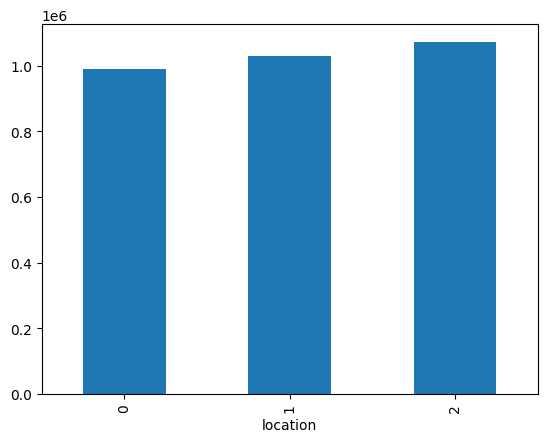

In [86]:
df.groupby("location")["price"].mean().plot(kind="bar")

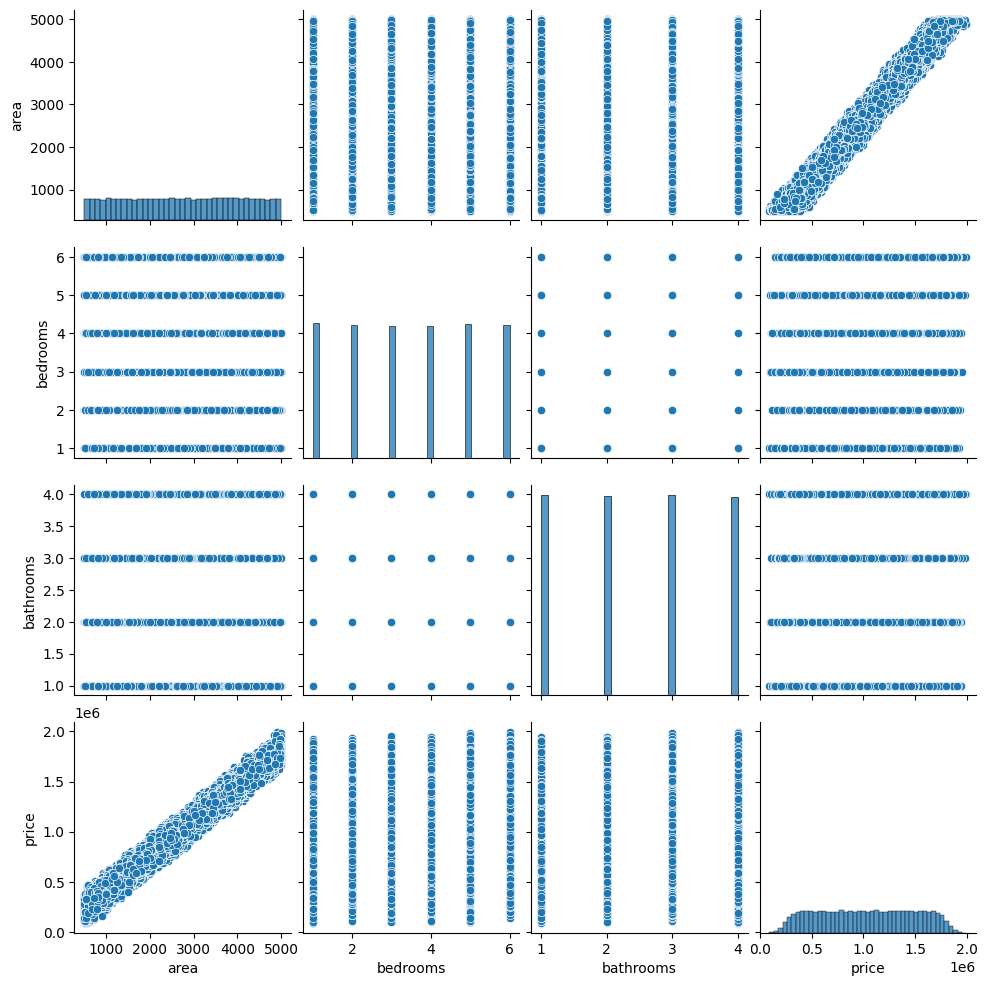

In [87]:
sns.pairplot(df[["area","bedrooms","bathrooms","price"]])

In [88]:
x = df[['area', 'bedrooms', 'bathrooms', 'floors', 'location', 'income_level']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1603715196.8427303
R^2 Score: 0.9923866184885983


/Users/yashraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yashraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yashraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [89]:
new_data = pd.DataFrame([[3000, 4, 1, 2, 1, 1]], columns=x.columns)
y_pred = model.predict(new_data)
print(f'Predicted Price: {y_pred}')

Predicted Price: [1109535.53822902]


In [90]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)